<a href="https://colab.research.google.com/github/oszavla/Dirac-Schwarz/blob/main/Aproksimasi_Wentzel_Kramers_Brillouin_(WKB).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kuantisasi Energi dan Lebar Keadaan Terikat


In [ ]:


import numpy as np
import pandas as pd
from IPython.display import display

kappas = [-10, -5, -4,-3 ,-2, -1, 1, 2,3, 4, 5, 10]
N_r_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
alpha_prime = 1.0

# Create a dictionary to store epsilon values
epsilon_data = {}

print("--------------ALLOWED ENERGΥ (E/mc^2) ------------")
for k in kappas:
    epsilon_data[k] = []
    for n_r in N_r_values:
        # Energy quantization formula for ̵
        # Pre-calculating the term to avoid negative values in sqrt
        # Rule 1: Cannot have negative radial nodes (n >= |k|) then it must be n_r < |k|
        if n_r > abs(k):
           epsilon = np.nan
        elif n_r == 0 and k > 0:
        # Rule 2: For n_r = 0, kappa MUST be negative (aligned spin)
           epsilon = np.nan
        else:
           term = 1 - ((alpha_prime / (n_r + np.abs(k) + 0.5))**2)
           epsilon = np.sqrt(term) if term >= 0 else np.nan


        epsilon_data[k].append(epsilon)

# Create DataFrame
df_epsilon = pd.DataFrame.from_dict(epsilon_data, orient='index', columns=[f'n_r={n_r}' for n_r in N_r_values])
df_epsilon.index.name = 'κ'

# Display the table with formatting

display(df_epsilon.style.format("{:.6f}", na_rep="N/A").background_gradient(cmap='viridis', axis=None))

print("--------------TRANSMISSION COEFFICIENT------------")
term1 = (np.pi * df_epsilon) / (np.pi * df_epsilon)
exponent_values = -np.pi * (df_epsilon.index ** 2) / (4 * alpha_prime)
T = np.exp(exponent_values)
df_T = term1
df_T = df_T.multiply(T, axis=0)
# Multiply by term3 along the rows (axis=0) so each kappa aligns with its row

# Set the index name just to be thorough
df_T.index.name = 'κ'

display(df_T.style.format("{:.6e}", na_rep="N/A").background_gradient(cmap='viridis', axis=None))

print("--------------ENERGI WIDTH (DECAY CONSTANT) ------------")

term1 = 1 / (np.pi * df_epsilon)
term2 = np.power(1 - df_epsilon**2, 1.5)
exponent_values = -np.pi * (df_epsilon.index ** 2) / (4 * alpha_prime)
term3 = np.exp(exponent_values)
df_gamma = term1 * term2

# Multiply by term3 along the rows (axis=0) so each kappa aligns with its row
df_gamma = df_gamma.multiply(term3, axis=0)

# Set the index name just to be thorough
df_gamma.index.name = 'κ'

display(df_gamma.style.format("{:.6e}", na_rep="N/A").background_gradient(cmap='viridis', axis=None))

--------------ALLOWED ENERGΥ (E/mc^2) ------------


,n_r=0,n_r=1,n_r=2,n_r=3,n_r=4,n_r=5,n_r=6,n_r=7,n_r=8,n_r=9,n_r=10
κ,,,,,,,,,,,
-10,0.995455,0.996212,0.996795,0.997253,0.997619,0.997917,0.998162,0.998366,0.998538,0.998684,0.998810
-5,0.983332,0.988095,0.991071,0.993055,0.994444,0.995455,N/A,N/A,N/A,N/A,N/A
-4,0.974996,0.983332,0.988095,0.991071,0.993055,N/A,N/A,N/A,N/A,N/A,N/A
-3,0.958315,0.974996,0.983332,0.988095,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-2,0.916515,0.958315,0.974996,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-1,0.745356,0.916515,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,N/A,0.916515,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
2,N/A,0.958315,0.974996,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,N/A,0.974996,0.983332,0.988095,N/A,N/A,N/A,N/A,N/A,N/A,N/A


--------------TRANSMISSION COEFFICIENT------------


,n_r=0,n_r=1,n_r=2,n_r=3,n_r=4,n_r=5,n_r=6,n_r=7,n_r=8,n_r=9,n_r=10
κ,,,,,,,,,,,
-10,7.773044e-35,7.773044e-35,7.773044e-35,7.773044e-35,7.773044e-35,7.773044e-35,7.773044e-35,7.773044e-35,7.773044e-35,7.773044e-35,7.773044e-35
-5,2.969257e-09,2.969257e-09,2.969257e-09,2.969257e-09,2.969257e-09,2.969257e-09,N/A,N/A,N/A,N/A,N/A
-4,3.487342e-06,3.487342e-06,3.487342e-06,3.487342e-06,3.487342e-06,N/A,N/A,N/A,N/A,N/A,N/A
-3,8.514383e-04,8.514383e-04,8.514383e-04,8.514383e-04,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-2,4.321392e-02,4.321392e-02,4.321392e-02,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-1,4.559381e-01,4.559381e-01,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,N/A,4.559381e-01,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
2,N/A,4.321392e-02,4.321392e-02,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,N/A,8.514383e-04,8.514383e-04,8.514383e-04,N/A,N/A,N/A,N/A,N/A,N/A,N/A


--------------ENERGI WIDTH (DECAY CONSTANT) ------------


,n_r=0,n_r=1,n_r=2,n_r=3,n_r=4,n_r=5,n_r=6,n_r=7,n_r=8,n_r=9,n_r=10
κ,,,,,,,,,,,
-10,2.147098e-38,1.633037e-38,1.270883e-38,1.008404e-38,8.135281e-39,6.658124e-39,5.518087e-39,4.624208e-39,3.913465e-39,3.341252e-39,2.875392e-39
-5,5.777096e-12,3.483046e-12,2.260525e-12,1.549771e-12,1.108528e-12,8.201789e-13,N/A,N/A,N/A,N/A,N/A
-4,1.249408e-08,6.785102e-09,4.090779e-09,2.654948e-09,1.820180e-09,N/A,N/A,N/A,N/A,N/A,N/A
-3,6.596157e-06,3.050443e-06,1.656590e-06,9.987681e-07,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-2,9.605370e-04,3.347815e-04,1.548223e-04,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-1,5.769239e-02,1.013436e-02,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,N/A,1.013436e-02,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
2,N/A,3.347815e-04,1.548223e-04,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,N/A,3.050443e-06,1.656590e-06,9.987681e-07,N/A,N/A,N/A,N/A,N/A,N/A,N/A


## Rentang energi jika $\alpha'$ semakin besar

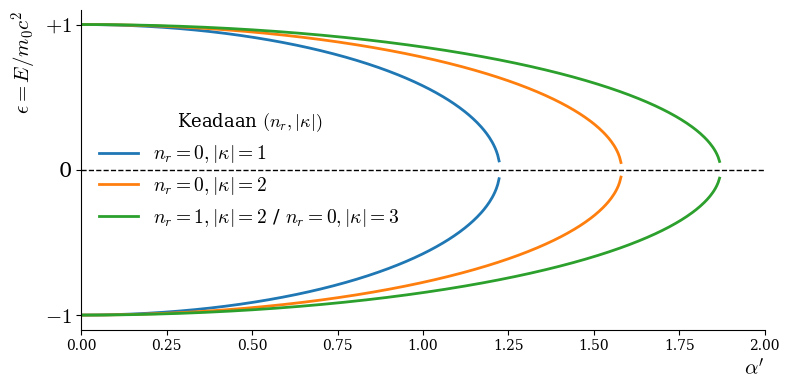

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate alpha_prime values
# Extended slightly past sqrt(1.5) to show the termination of the lowest state
alpha_prime = np.linspace(0, 2.0, 500)

# Define the new energy function
def calc_epsilon(alpha, n_r, kappa_abs):
    denominator = n_r + kappa_abs + 0.5
    # Find valid domain where the expression inside the sqrt is non-negative
    valid = (alpha**2) <= denominator

    # Initialize array with NaNs to prevent plotting imaginary values
    E = np.full_like(alpha, np.nan)
    E[valid] = np.sqrt(1 - (alpha[valid]**2) / denominator)
    return E

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Define the allowed states based on n_r < |\kappa|
states = [
    {"n_r": 0, "kappa": 1, "label": r"$n_r=0, |\kappa|=1$", "color": "#1f77b4"},
    {"n_r": 0, "kappa": 2, "label": r"$n_r=0, |\kappa|=2$", "color": "#ff7f0e"},
    # We combine (1,2) and (0,3) in the legend since they are mathematically degenerate here
    {"n_r": 1, "kappa": 2, "label": r"$n_r=1, |\kappa|=2$ / $n_r=0, |\kappa|=3$", "color": "#2ca02c"},
]

# Plot each state
for state in states:
    E_pos = calc_epsilon(alpha_prime, state["n_r"], state["kappa"])

    # Positive branch
    ax.plot(alpha_prime, E_pos, label=state["label"], color=state["color"], linewidth=2)
    # Negative branch
    ax.plot(alpha_prime, -E_pos, color=state["color"], linewidth=2)

# Formatting the axes and limits
ax.set_xlim(0, max(alpha_prime))
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(r'$\alpha^\prime$', fontsize=15, loc='right')
ax.set_ylabel(r'$\epsilon = E/m_0c^2$', fontsize=15, loc='top')
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels([r'$-1$', '0', r'$+1$'], fontsize=15)

# Spine formatting for standard physics textbook look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='black', linewidth=1, linestyle='--')

# Add legend
ax.legend(title=r"Keadaan $(n_r, |\kappa|)$", loc='center left', frameon=False, fontsize=14, title_fontsize=13)

plt.tight_layout()
plt.show()

### Konversi $\TeX$

In [ ]:
import pandas as pd

# Create the styler object with formatting and gradient
styler = df_epsilon.style.format("{:.6f}", na_rep=" - ").background_gradient(cmap='viridis', axis=None)

# Prepare the LaTeX string with the specific requested wrapper
latex_table_content = styler.to_latex(
    column_format="l" + "c" * len(df_epsilon.columns),
    hrules=True,
    convert_css=True
)

# Custom Header to match requested format exactly
header = r"""\begin{table}[h]
\centering
\caption{Nilai eigen energi $\epsilon=E/m_0c^2 $ yang didapat dari Aproksimasi WKB}
\label{tab:epsilon_eigenvalues}
\resizebox{\textwidth}{!}{%
"""

# Using raw strings to avoid SyntaxWarnings with backslashes
final_table = latex_table_content.replace(r"\midrule", r"\midrule")

# Format the index/header area to include the kappa symbol
# We remove the automatically generated header line that has the dummy index name
lines = final_table.split('\n')
# Find the line starting the headers and replace the first empty cell with kappa
for i, line in enumerate(lines):
    if ' & n=0' in line:
        lines[i] = line.replace(' & n=0', r'$\kappa$ & n = 0')
    # Ensure n=1, n=2 etc have spaces
    if 'n=' in lines[i]:
        for n_val in range(1, 11):
            lines[i] = lines[i].replace(f'n={n_val}', f'n = {n_val}')

# Remove the extra line with the '̴' placeholder often generated by pandas index names
lines = [l for l in lines if '̴' not in l]

final_table = '\n'.join(lines)

footer = r"""}
\end{table}"""

print("--- COPY THIS INTO YOUR LATEX PREAMBLE ---")
print("\\usepackage[table]{xcolor}")
print("\\usepackage{booktabs}")
print("\\usepackage{graphicx}")
print("\n--- COPY THIS INTO YOUR LATEX DOCUMENT ---")
print(header + final_table + footer)

--- COPY THIS INTO YOUR LATEX PREAMBLE ---
\usepackage[table]{xcolor}
\usepackage{booktabs}
\usepackage{graphicx}

--- COPY THIS INTO YOUR LATEX DOCUMENT ---
\begin{table}[h]
\centering
\caption{Nilai eigen energi $\epsilon=E/m_0c^2 $ yang didapat dari Aproksimasi WKB}
\label{tab:epsilon_eigenvalues}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccccccc}
\toprule
 & n_r=0 & n_r=1 & n_r=2 & n_r=3 & n_r=4 & n_r=5 & n_r=6 & n_r=7 & n_r=8 & n_r=9 & n_r=10 \\
κ &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
-10 & {\cellcolor[HTML]{F6E620}} \color[HTML]{000000} 0.995037 & {\cellcolor[HTML]{F8E621}} \color[HTML]{000000} 0.995897 & {\cellcolor[HTML]{FBE723}} \color[HTML]{000000} 0.996551 & {\cellcolor[HTML]{FBE723}} \color[HTML]{000000} 0.997060 & {\cellcolor[HTML]{FBE723}} \color[HTML]{000000} 0.997464 & {\cellcolor[HTML]{FDE725}} \color[HTML]{000000} 0.997790 & {\cellcolor[HTML]{FDE725}} \color[HTML]{000000} 0.998057 & {\cellcolor[HTML]{FDE725}} \color[HTML]{000000} 0.998279 & {\cellcolor[H